<a href="https://colab.research.google.com/github/deekshithap-07/deekshithap-07/blob/main/Digital_Twin_Cardiac_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Personalized Digital Twin for Predictive Cardiac Risk Monitoring
Run the single cell below in Google Colab (Runtime > Run all). Sliders let you enter live values and see the risk, reason, and confidence for that reading.

Wearable connected. Learning this patient's personal normal rhythm...

Day 1: HR = 72.9 bpm | HRV = 51.9 ms
Day 2: HR = 71.5 bpm | HRV = 54.5 ms
Day 3: HR = 69.2 bpm | HRV = 55.9 ms
Day 4: HR = 70.7 bpm | HRV = 47.5 ms
Day 5: HR = 71.0 bpm | HRV = 63.3 ms
Day 6: HR = 74.5 bpm | HRV = 58.7 ms
Day 7: HR = 72.4 bpm | HRV = 47.3 ms

Digital Twin established.
Personal normal Heart Rate : 71.8 bpm
Personal normal HRV        : 54.2 ms



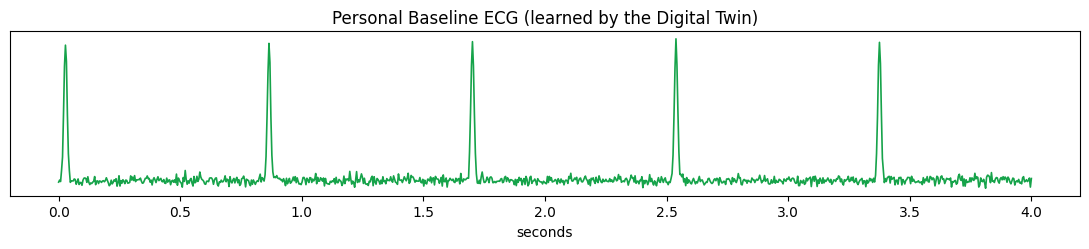

In [2]:
# ============================================================
# DIGITAL HEART TWIN — Predictive Cardiac Risk Simulation
# Run this cell in Google Colab (Runtime > Run all)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import time

plt.rcParams['figure.facecolor'] = 'white'

# ------------------------------------------------------------
# STEP 0: Show the practical working flow (what happens on the real wearable)
# ------------------------------------------------------------
display(HTML("""
<div style="width:100%;padding:18px;background:#0f172a;border-radius:12px;color:white;font-family:Arial, sans-serif;margin-bottom:15px;">
<h2 style="margin-top:0;">Digital Heart Twin — System Simulation</h2>
<p style="color:#94a3b8;margin-bottom:6px;">Simulated pipeline (this is what the wearable + backend does in real life):</p>
<div style="display:flex;flex-wrap:wrap;gap:8px;font-size:13px;">
<div style="background:#1e293b;padding:8px 12px;border-radius:8px;">Wearable captures ECG</div>
<div style="background:#1e293b;padding:8px 12px;border-radius:8px;">Noise removed</div>
<div style="background:#1e293b;padding:8px 12px;border-radius:8px;">Compared to personal Digital Twin</div>
<div style="background:#1e293b;padding:8px 12px;border-radius:8px;">DCRI calculated</div>
<div style="background:#1e293b;padding:8px 12px;border-radius:8px;">Risk + reason generated</div>
<div style="background:#1e293b;padding:8px 12px;border-radius:8px;">Alert sent if risk is high</div>
</div>
</div>
"""))

# ------------------------------------------------------------
# STEP 1: Synthetic ECG waveform generator (visual only, for realism)
# ------------------------------------------------------------
def generate_ecg(heart_rate=72, duration=4, noise=0.02):
    fs = 250
    t = np.linspace(0, duration, int(fs * duration))
    ecg = np.zeros_like(t)
    beat_interval = 60 / heart_rate
    for beat_time in np.arange(0, duration, beat_interval):
        idx = int(beat_time * fs)
        width = int(fs * 0.06)
        if idx + width < len(ecg):
            x = np.linspace(-3, 3, width)
            ecg[idx:idx + width] += np.exp(-x ** 2)
    ecg += np.random.normal(0, noise, len(t))
    return t, ecg

# ------------------------------------------------------------
# STEP 2: Simulated 7-day Digital Twin baseline learning phase
# ------------------------------------------------------------
def build_digital_twin():
    print("Wearable connected. Learning this patient's personal normal rhythm...\n")
    hr_log, hrv_log = [], []
    for day in range(1, 8):
        hr = np.random.normal(72, 3)
        hrv = np.random.normal(55, 5)
        hr_log.append(hr); hrv_log.append(hrv)
        print(f"Day {day}: HR = {hr:.1f} bpm | HRV = {hrv:.1f} ms")
        time.sleep(0.25)
    twin = {"baseline_hr": float(np.mean(hr_log)), "baseline_hrv": float(np.mean(hrv_log))}
    print(f"\nDigital Twin established.")
    print(f"Personal normal Heart Rate : {twin['baseline_hr']:.1f} bpm")
    print(f"Personal normal HRV        : {twin['baseline_hrv']:.1f} ms\n")
    return twin

twin = build_digital_twin()

# Plot the baseline ECG once, so the audience sees a "normal" reference waveform
t, ecg = generate_ecg(heart_rate=twin["baseline_hr"])
plt.figure(figsize=(11, 2.6))
plt.plot(t, ecg, color="#16a34a", linewidth=1.2)
plt.title("Personal Baseline ECG (learned by the Digital Twin)")
plt.xlabel("seconds"); plt.yticks([])
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# STEP 3: The APCRA-style algorithm — DCRI calculation
# ------------------------------------------------------------
def calculate_dcri(hr, hrv, ecg_deviation, motion, signal_quality, twin):
    hr_diff = abs(hr - twin["baseline_hr"])
    hr_score = max(0, 100 - hr_diff * 3)
    hrv_score = max(0, min(100, (hrv / twin["baseline_hrv"]) * 100))
    ecg_score = max(0, 100 - ecg_deviation * 1.2)

    # Weighted combination -> Dynamic Cardiac Resilience Index (0-100)
    dcri = hrv_score * 0.40 + ecg_score * 0.35 + hr_score * 0.25
    dcri = max(0, min(100, dcri))
    risk = max(0, min(100, 100 - dcri))
    confidence = max(50, signal_quality - motion * 0.3)

    reasons = []
    if hrv_score < 70:
        reasons.append(f"HRV reduced vs personal baseline ({hrv:.0f} ms vs {twin['baseline_hrv']:.0f} ms)")
    if ecg_score < 70:
        reasons.append(f"ECG pattern deviates {ecg_deviation:.0f}% from this patient's normal rhythm")
    if hr_score < 70:
        reasons.append(f"Heart rate differs from personal baseline ({hr:.0f} bpm vs {twin['baseline_hr']:.0f} bpm)")
    if motion > 60:
        reasons.append("High motion detected — may reduce signal reliability")
    if signal_quality < 70:
        reasons.append("Signal quality is low — prediction confidence reduced")
    if not reasons:
        reasons.append("All parameters are within this patient's personal normal range")

    return dcri, risk, confidence, reasons

def risk_band(risk):
    if risk < 15:
        return "Excellent", "#16a34a"
    elif risk < 30:
        return "Stable", "#65a30d"
    elif risk < 50:
        return "Monitor", "#eab308"
    else:
        return "High Risk", "#dc2626"

# ------------------------------------------------------------
# STEP 4: Interactive dashboard (this is the live demo you run on stage)
# ------------------------------------------------------------
style = {"description_width": "160px"}
layout = widgets.Layout(width="480px")

hr_slider     = widgets.IntSlider(value=72, min=40, max=180, description="Heart Rate (bpm):", style=style, layout=layout)
hrv_slider    = widgets.IntSlider(value=55, min=10, max=100, description="HRV (ms):", style=style, layout=layout)
ecgdev_slider = widgets.IntSlider(value=5,  min=0,  max=100, description="ECG Deviation (%):", style=style, layout=layout)
motion_slider = widgets.IntSlider(value=10, min=0,  max=100, description="Motion Level (%):", style=style, layout=layout)
signal_slider = widgets.IntSlider(value=95, min=0,  max=100, description="Signal Quality (%):", style=style, layout=layout)

analyze_btn = widgets.Button(description="Run APCRA Analysis", button_style="success",
                              layout=widgets.Layout(width="220px", height="38px"))
output = widgets.Output()

def on_click(b):
    with output:
        clear_output()
        hr, hrv, dev, mot, sq = (hr_slider.value, hrv_slider.value, ecgdev_slider.value,
                                  motion_slider.value, signal_slider.value)
        dcri, risk, conf, reasons = calculate_dcri(hr, hrv, dev, mot, sq, twin)
        label, color = risk_band(risk)

        t2, ecg2 = generate_ecg(heart_rate=hr, noise=0.02 + dev / 500)
        fig, axes = plt.subplots(1, 2, figsize=(11, 3), gridspec_kw={"width_ratios": [2, 1]})

        axes[0].plot(t2, ecg2, color=color, linewidth=1.2)
        axes[0].set_title("Live ECG vs Personal Baseline")
        axes[0].plot(t, ecg, color="#94a3b8", linewidth=0.8, alpha=0.6)
        axes[0].set_yticks([]); axes[0].set_xlabel("seconds")

        axes[1].pie([dcri, 100 - dcri], colors=[color, "#e5e7eb"], startangle=90,
                    counterclock=False, wedgeprops={"width": 0.35})
        axes[1].set_title("DCRI")
        axes[1].text(0, 0, f"{dcri:.0f}", ha="center", va="center", fontsize=22, fontweight="bold")
        plt.tight_layout()
        plt.show()

        reasons_html = "".join(f"<li>{r}</li>" for r in reasons)
        alert_html = ""
        if risk >= 50:
            alert_html = f"""
            <div style="margin-top:10px;padding:12px;background:#fee2e2;border-left:5px solid #dc2626;border-radius:6px;">
            <b>Simulated Emergency Alert (SMS/App):</b><br>
            "High Cardiac Risk Detected — Resilience Index {dcri:.0f}%. Please check on the patient."<br>
            <i>Location + Doctor Dashboard would update automatically in the real system.</i>
            </div>"""

        display(HTML(f"""
        <div style="width:100%;padding:18px;background:#f8fafc;border-radius:12px;border:1px solid #e2e8f0;font-family:Arial, sans-serif;">
          <div style="display:flex;justify-content:space-between;align-items:center;">
            <h3 style="margin:0;">Result: <span style="color:{color}">{label}</span></h3>
            <div style="font-size:14px;color:#475569;">Confidence: <b>{conf:.0f}%</b></div>
          </div>
          <p style="margin:10px 0 4px 0;"><b>DCRI Score:</b> {dcri:.1f}/100 &nbsp; | &nbsp; <b>Predicted Risk:</b> {risk:.1f}%</p>
          <p style="margin:4px 0;"><b>Reasoning (Explainable AI):</b></p>
          <ul style="margin-top:4px;">{reasons_html}</ul>
          {alert_html}
        </div>
        """))

analyze_btn.on_click(on_click)

display(HTML("<h3 style='font-family:Arial;'>Live Patient Monitoring Panel</h3>"))
display(widgets.VBox([hr_slider, hrv_slider, ecgdev_slider, motion_slider, signal_slider, analyze_btn, output]))

# ------------------------------------------------------------
# STEP 5: "What-if" Digital Twin simulation (Innovation 6 from the report)
# ------------------------------------------------------------
sleep_slider = widgets.IntSlider(value=7, min=2, max=9, description="Avg Sleep (hrs):", style=style, layout=layout)
whatif_btn = widgets.Button(description="Simulate Next 30 Days", button_style="warning",
                             layout=widgets.Layout(width="220px", height="38px"))
whatif_out = widgets.Output()

def on_whatif(b):
    with whatif_out:
        clear_output()
        sleep = sleep_slider.value
        days = np.arange(1, 31)
        sleep_penalty = max(0, (7 - sleep)) * 1.1
        resilience = 90 - sleep_penalty * (days / 30) * 25 + np.random.normal(0, 1.2, 30)
        resilience = np.clip(resilience, 0, 100)

        plt.figure(figsize=(10, 3))
        plt.plot(days, resilience, color="#2563eb", linewidth=2)
        plt.axhline(50, color="#dc2626", linestyle="--", linewidth=1, label="Risk threshold")
        plt.title(f"Projected Cardiac Resilience over 30 days at {sleep} hrs sleep/night")
        plt.xlabel("Day"); plt.ylabel("Resilience Index"); plt.legend()
        plt.tight_layout(); plt.show()

        end_val = resilience[-1]
        msg = "resilience stays healthy" if end_val > 70 else ("resilience gradually weakens" if end_val > 50 else "resilience drops into risk territory")
        display(HTML(f"<p style='font-family:Arial;'>At {sleep} hrs of sleep/night, the Digital Twin projects that <b>{msg}</b> by day 30 (projected score: {end_val:.0f}).</p>"))

whatif_btn.on_click(on_whatif)
display(HTML("<h3 style='font-family:Arial;margin-top:20px;'>What-if Simulation (Digital Twin Forecasting)</h3>"))
display(widgets.VBox([sleep_slider, whatif_btn, whatif_out]))
